In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Generate Samples

In [ ]:
NUM_SAMPLES = 100000
SEED = 42

Text(0.5, 1.0, 'Gaussian Histogram')

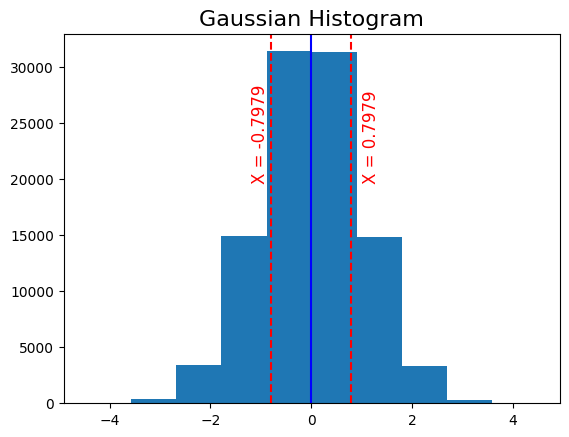

In [ ]:
# see a 1D gaussian
np.random.seed(SEED)
samples = np.random.normal(size=(NUM_SAMPLES,1))
plt.hist(samples)

x_value = np.sqrt(2 / np.pi)
plt.axvline(x=-x_value, color='red', linestyle='--', label=f'X = -{x_value:.4f}')
plt.axvline(x=x_value, color='red', linestyle='--', label=f'X = {x_value:.4f}')
plt.text(-x_value - 0.4, 20000, f'X = -{x_value:.4f}', color='red',
         rotation=90, fontsize=12)
plt.text(x_value + 0.2, 20000, f'X = {x_value:.4f}', color='red',
         rotation=90, fontsize=12)

plt.axvline(x=0, color='blue', label='X = 0')
plt.title('Gaussian Histogram', fontsize=16)

## Generate 2D gaussian samples

In [ ]:
np.random.seed(SEED)
samples = np.random.normal(size=(NUM_SAMPLES,2))

(np.float64(-4.896218248422408),
 np.float64(4.6352756211083035),
 np.float64(-4.916989792886066),
 np.float64(5.01350065297208))

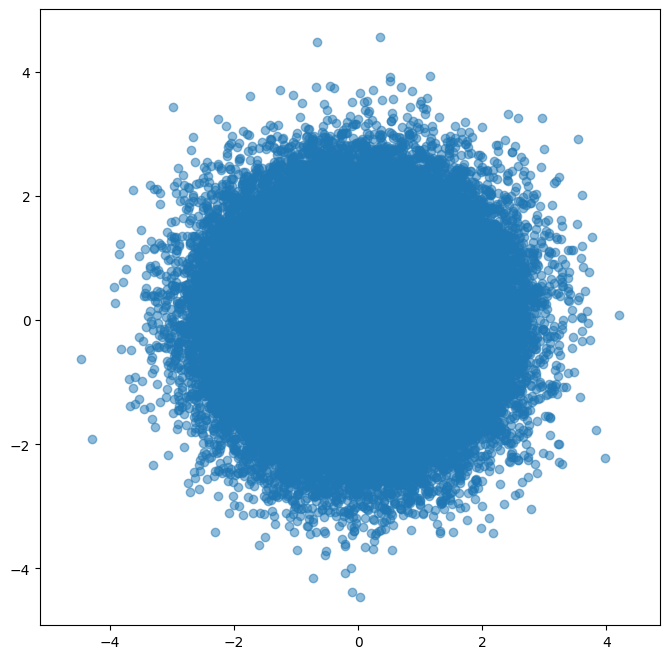

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(samples[:,0], samples[:,1], alpha=0.5)
ax.axis('equal')

# Run Clustering for a few different number of clusters

*NUM_CODEWORDS = 4*

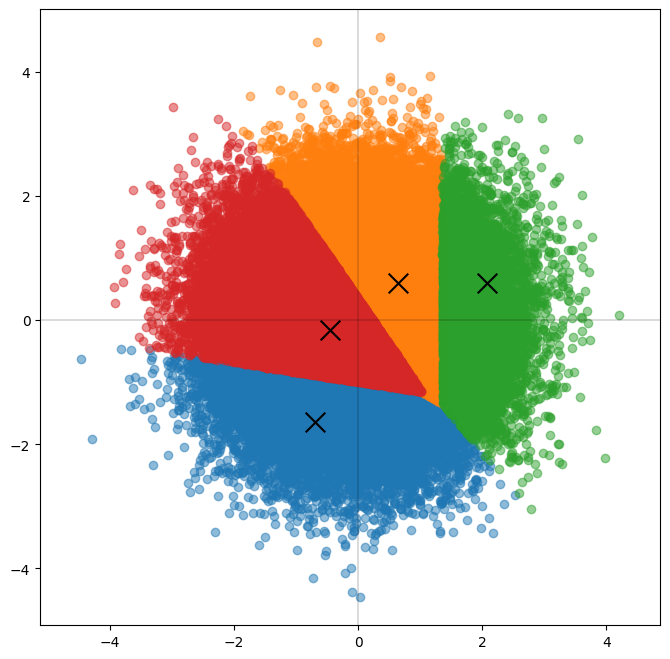

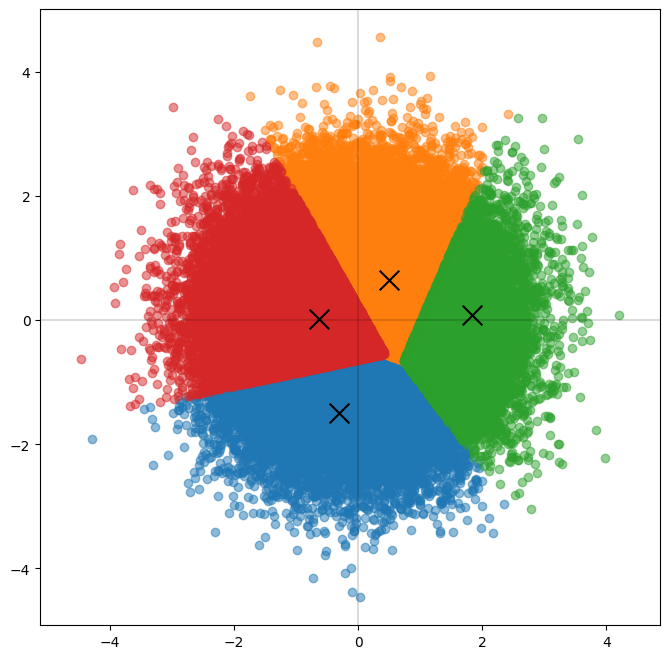

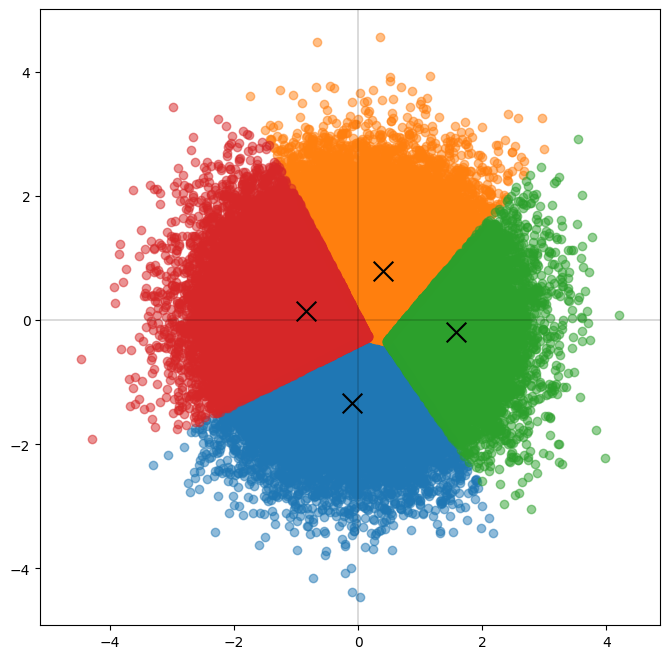

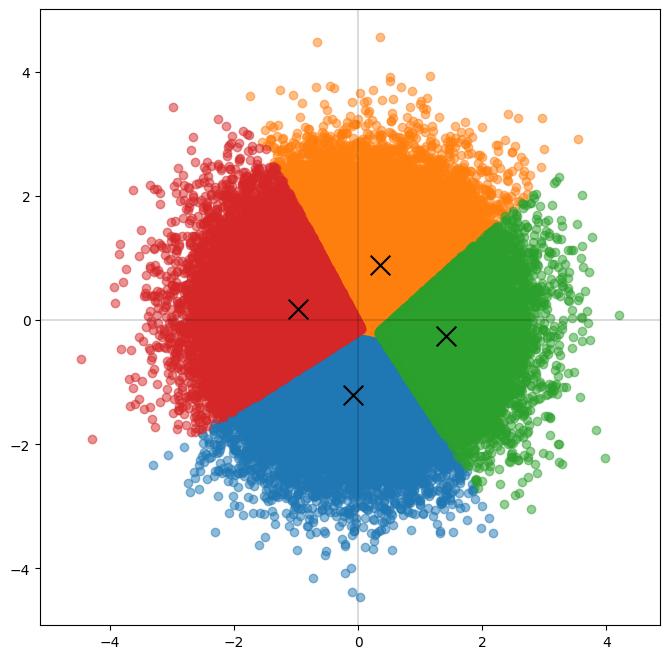

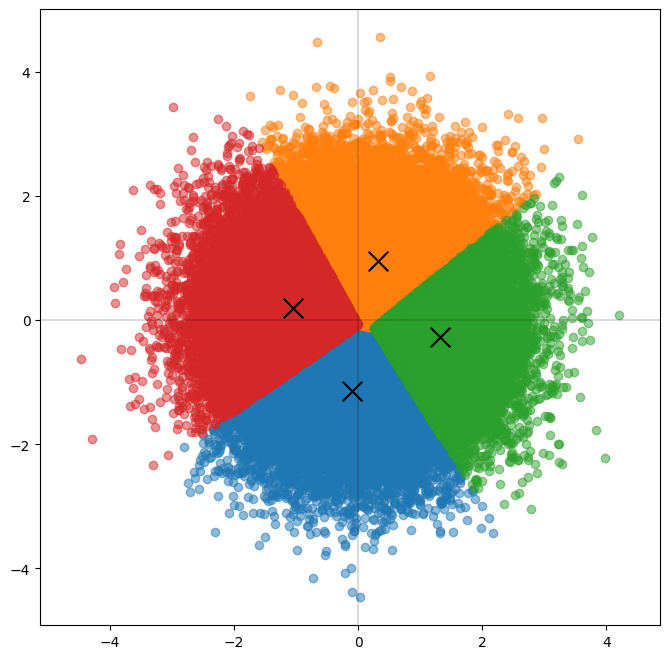

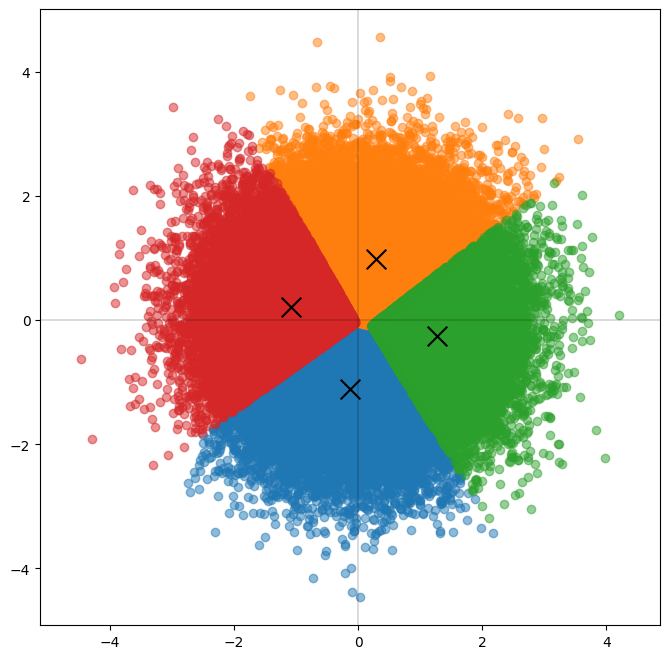

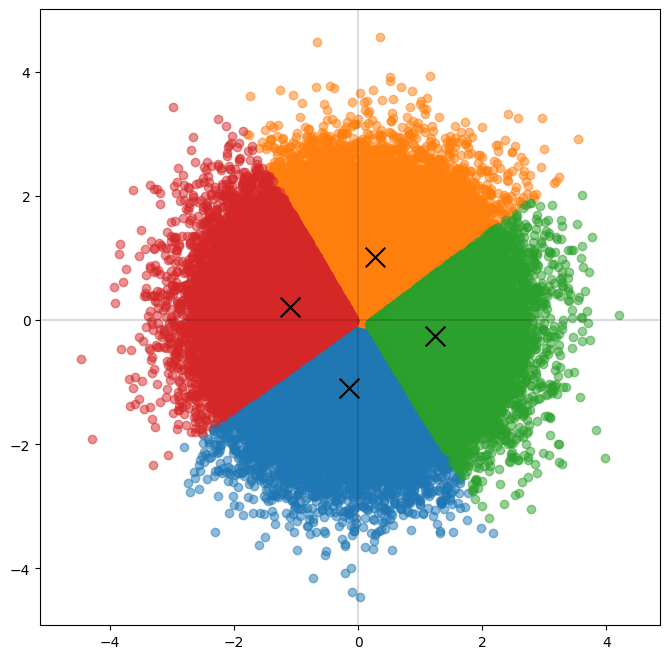

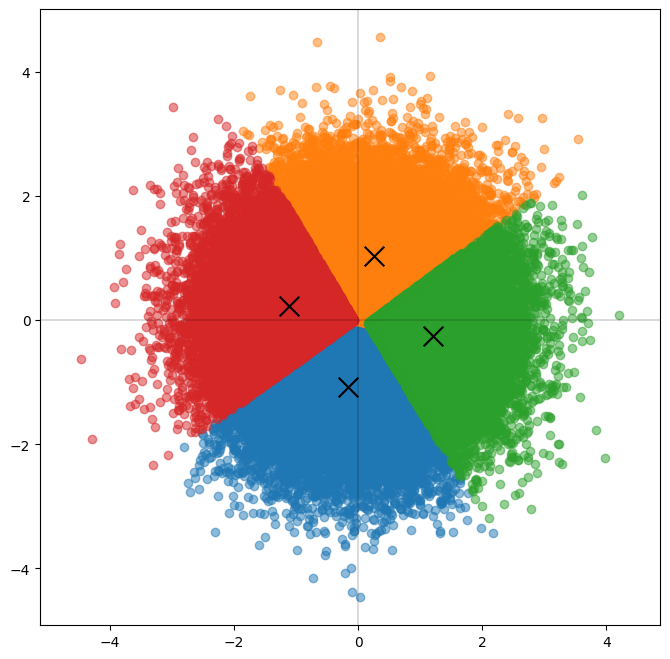

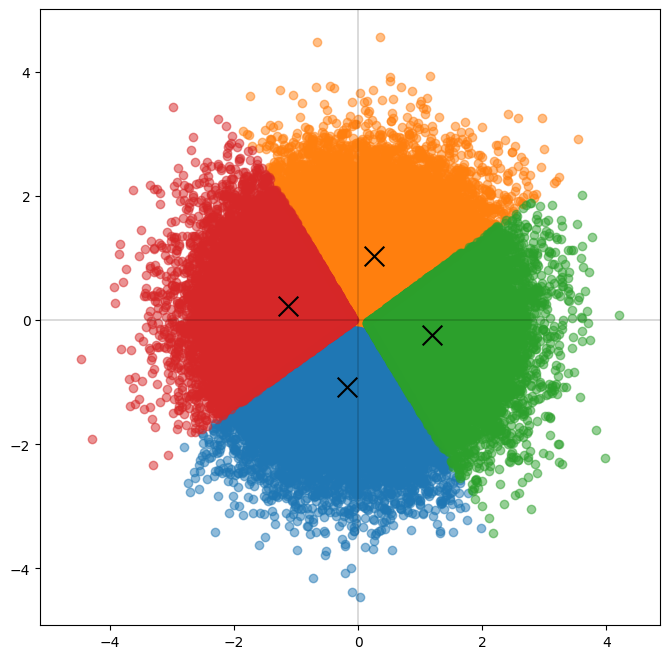

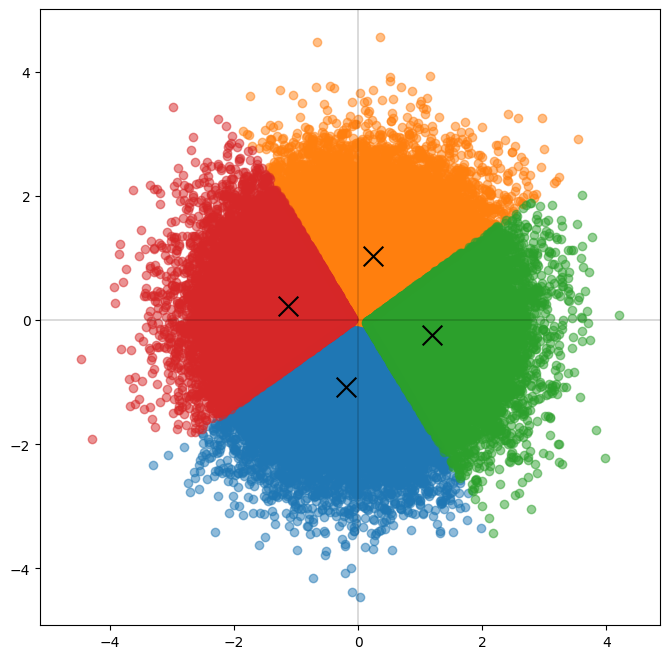

In [ ]:
SEED=200
NUM_CODEWORDS = 4
for num_iter in range(1,11):
  np.random.seed(SEED)
  initial_points = np.random.choice(NUM_SAMPLES, size=NUM_CODEWORDS, replace=False)
  initial_points = samples[initial_points,:]
  kmeans = KMeans(n_clusters= NUM_CODEWORDS, init=initial_points, n_init=1, max_iter=num_iter)
  labels = kmeans.fit_predict(samples)
  fig, ax = plt.subplots(figsize=(8, 8))
  centroids = kmeans.cluster_centers_
  for i in range(NUM_CODEWORDS):
    plt.scatter(samples[labels == i, 0] , samples[labels == i, 1] , label = i, alpha=0.5)
  plt.scatter(centroids[:,0] , centroids[:,1] , s = 200, color = 'k', marker = 'x')
  plt.axvline(x=0, c="k", linewidth=0.2)
  plt.axhline(y=0, c="k", linewidth=0.2)
  ax.axis('equal')

*NUM_CODEWORDS = 8*

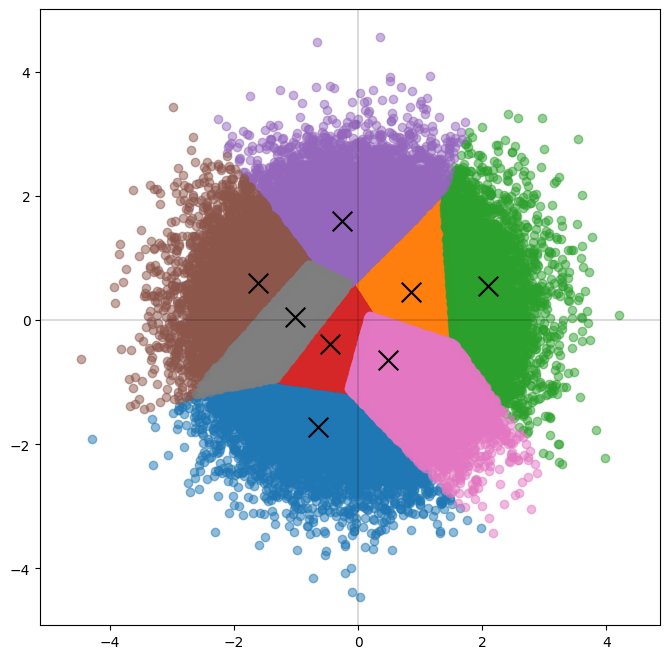

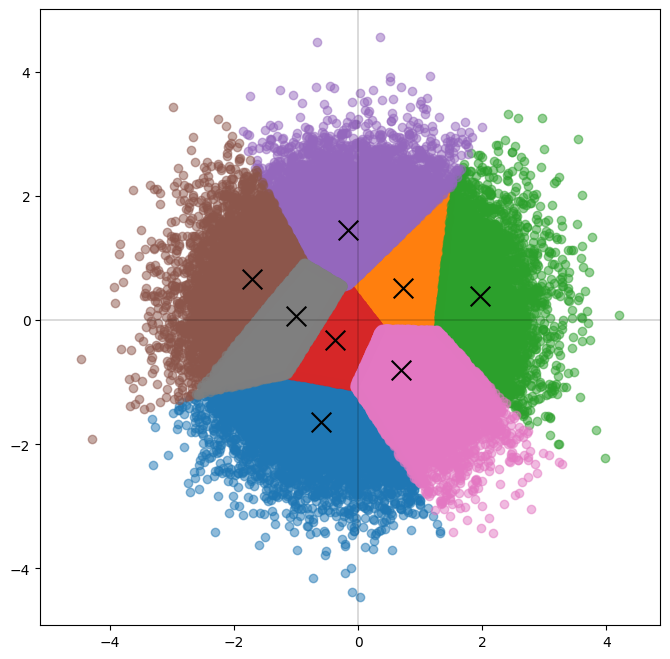

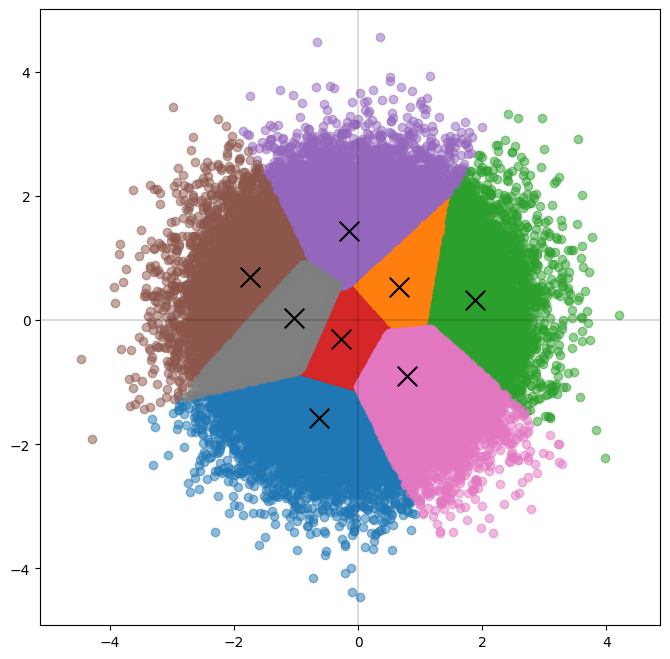

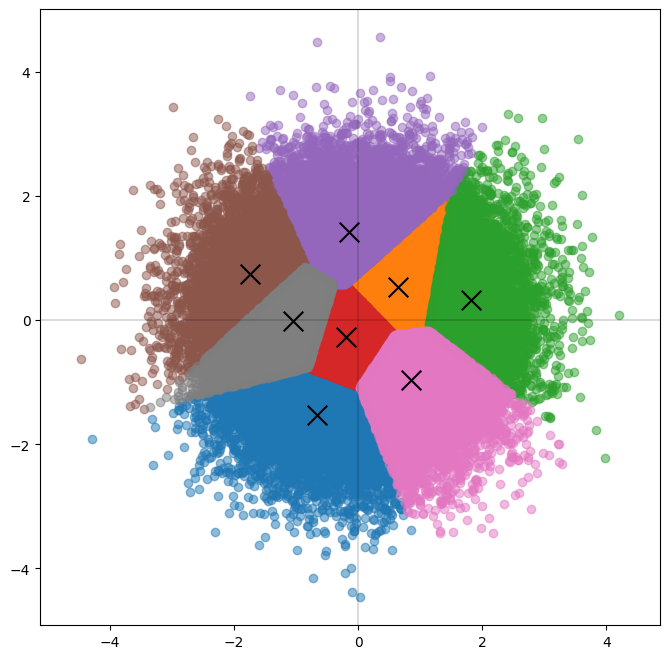

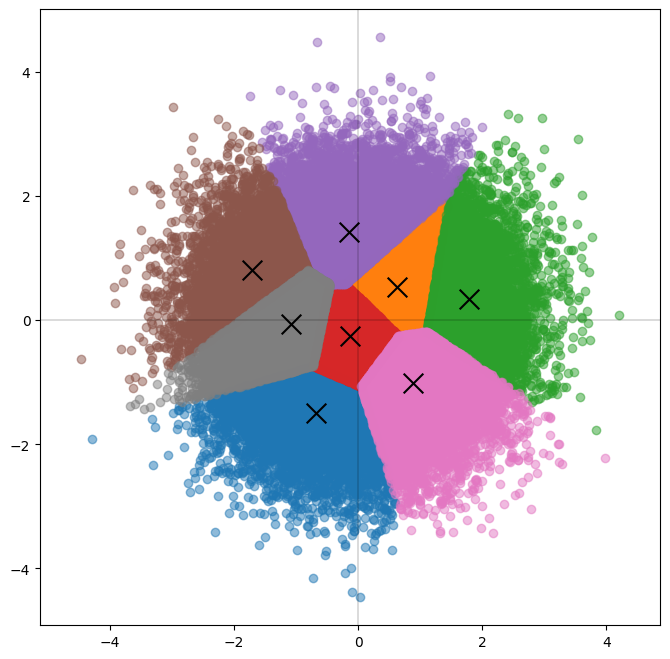

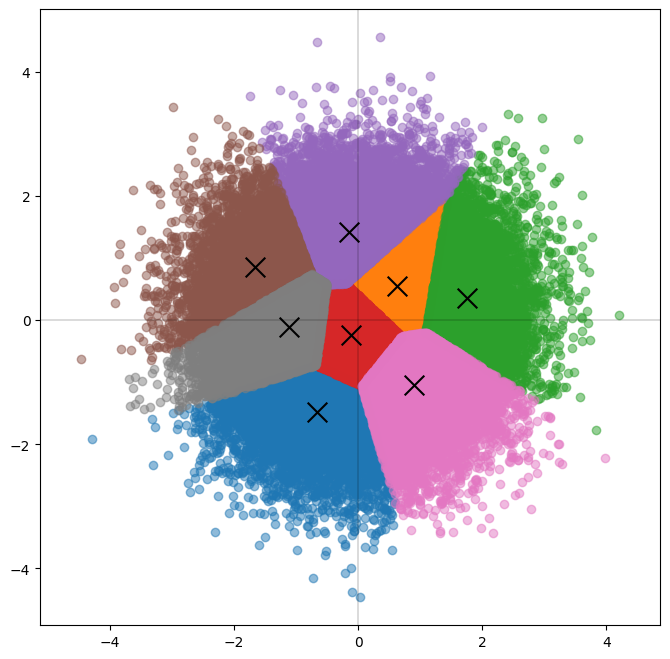

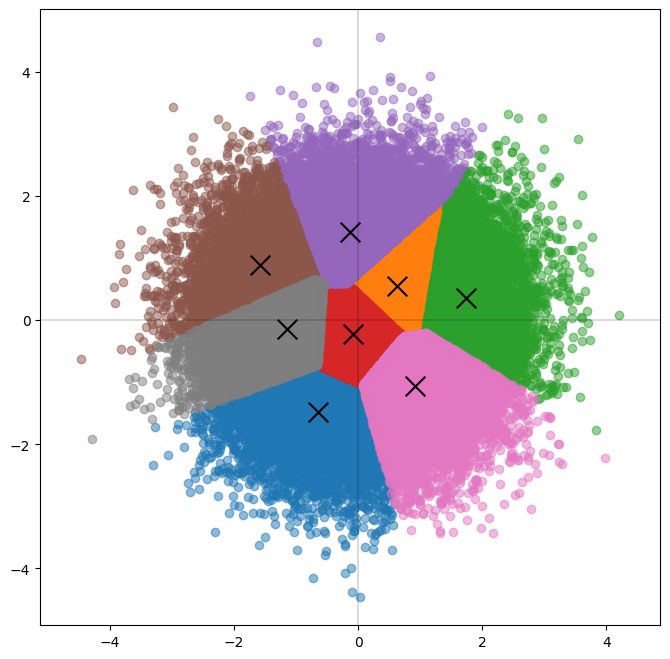

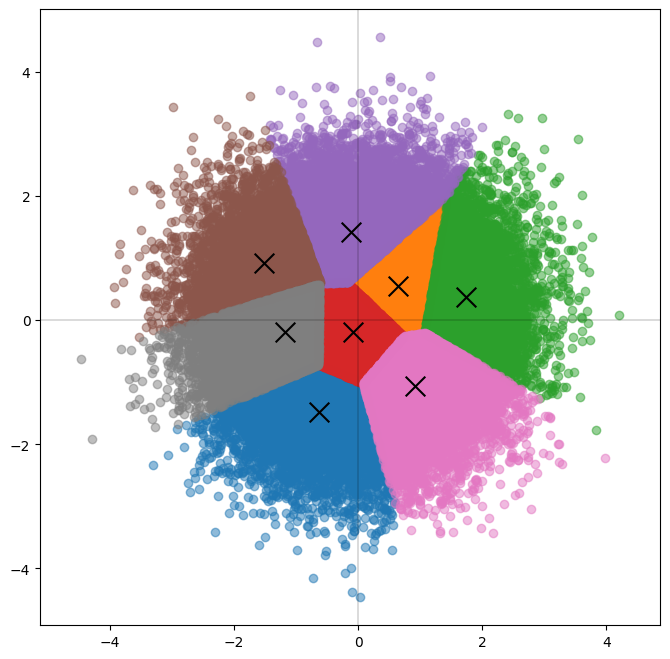

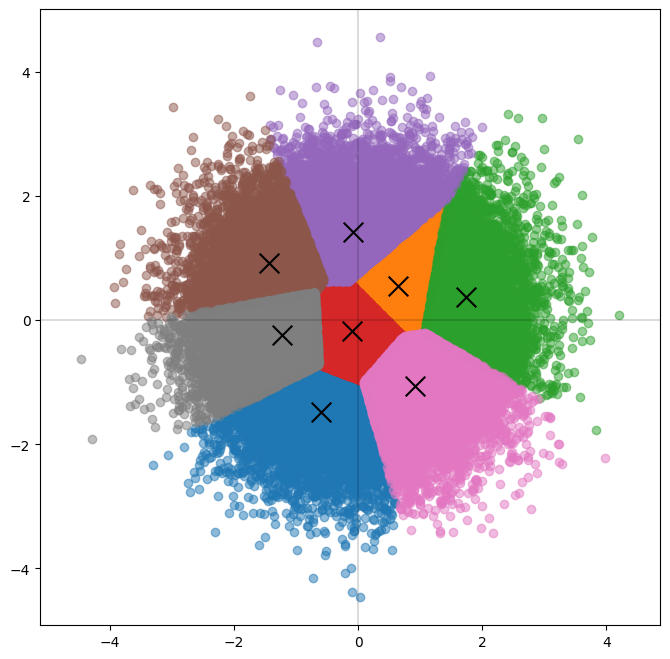

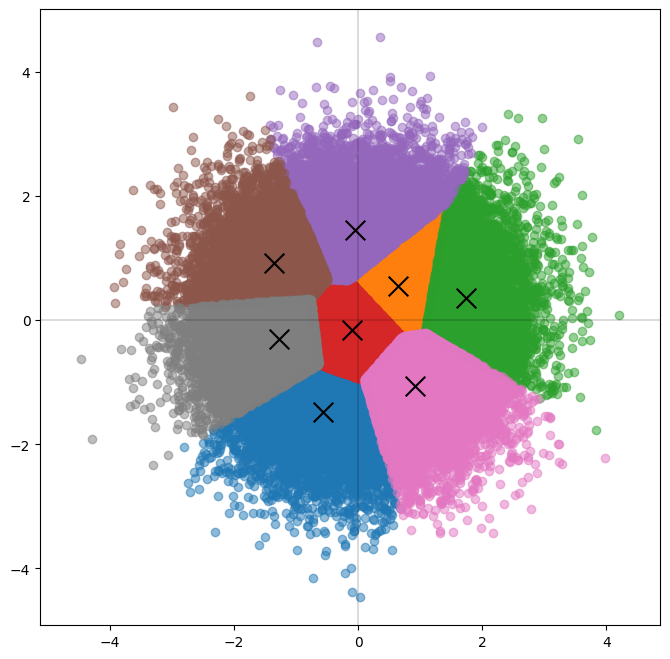

In [ ]:
NUM_CODEWORDS = 8
for num_iter in range(1,11):
  np.random.seed(SEED)
  initial_points = np.random.choice(NUM_SAMPLES, size=NUM_CODEWORDS, replace=False)
  initial_points = samples[initial_points,:]
  kmeans = KMeans(n_clusters= NUM_CODEWORDS, init=initial_points, n_init=1, max_iter=num_iter)
  labels = kmeans.fit_predict(samples)
  fig, ax = plt.subplots(figsize=(8, 8))
  centroids = kmeans.cluster_centers_
  for i in range(NUM_CODEWORDS):
    plt.scatter(samples[labels == i, 0] , samples[labels == i, 1] , label = i, alpha=0.5)
  plt.scatter(centroids[:,0] , centroids[:,1] , s = 200, color = 'k', marker = 'x')
  plt.axvline(x=0, c="k", linewidth=0.2)
  plt.axhline(y=0, c="k", linewidth=0.2)
  ax.axis('equal')

# Plot Distortion vs Iteration
*NUM_CODEWORDS = 8*

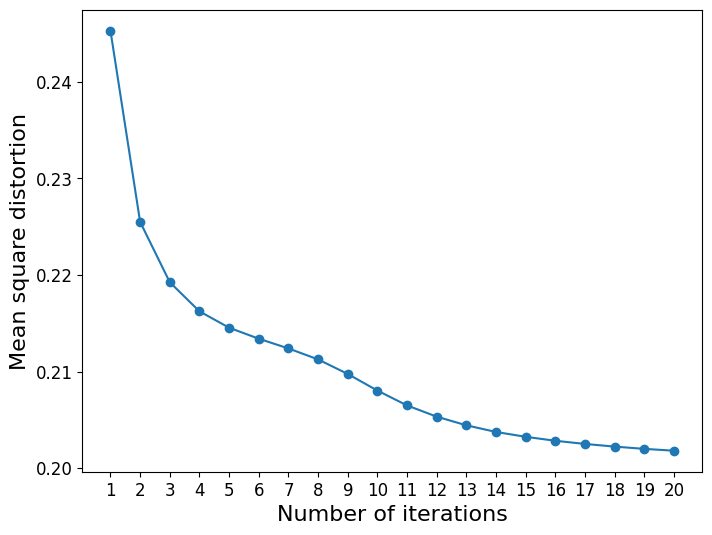

In [ ]:
# plotting distortion vs. iteration
distortions = []
MAX_ITERS = 21
for num_iter in range(1,MAX_ITERS):
  np.random.seed(SEED)
  initial_points = np.random.choice(NUM_SAMPLES, size=NUM_CODEWORDS, replace=False)
  initial_points = samples[initial_points,:]
  kmeans = KMeans(n_clusters= NUM_CODEWORDS, init=initial_points, n_init=1, max_iter=num_iter)
  labels = kmeans.fit_predict(samples)
  distortions.append(kmeans.inertia_/NUM_SAMPLES/2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(1,MAX_ITERS), distortions, 'o-')
ax.set_xticks(range(1,MAX_ITERS))
ax.set_xlabel("Number of iterations", fontsize=16)
ax.set_ylabel("Mean square distortion", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

# Plot Distortion vs Size of Codebook

In [ ]:
# plotting distortion vs. codebook size
distortions, rates = [], []
MAX_CODEBOOK_SIZE = 25
for num_codewords in range(2, MAX_CODEBOOK_SIZE):
  np.random.seed(SEED)
  initial_points = np.random.choice(NUM_SAMPLES, size=num_codewords, replace=False)
  initial_points = samples[initial_points,:]
  kmeans = KMeans(n_clusters= num_codewords, init=initial_points, n_init=1, max_iter=10000)
  labels = kmeans.fit_predict(samples)
  distortions.append(kmeans.inertia_/NUM_SAMPLES/2)
  rate = NUM_SAMPLES*np.log2(num_codewords)/2
  rates.append(rate)

uncompressed_rate = NUM_SAMPLES*np.log2(NUM_SAMPLES)/2
compression_ratio = uncompressed_rate/rates

1 0.6811511886315819
2 0.4630972342794912
3 0.36295848556488003
4 0.30669724900079315
5 0.2531494238313913
6 0.22183622818663484
7 0.20083229237555922
8 0.18233641142776164
9 0.16751019504551656
10 0.15130239571712287
11 0.14163195692376374
12 0.13207966874575372
13 0.12144628740352875
14 0.11386610344871734
15 0.10695670525518133
16 0.10223714806054814
17 0.09732339342406374
18 0.09265244126864124
19 0.08816625757149112
20 0.08386005522103736
21 0.08062260827904172
22 0.07768963104396685
23 0.07477816965401918
[ 0.49671415 -0.1382643 ]


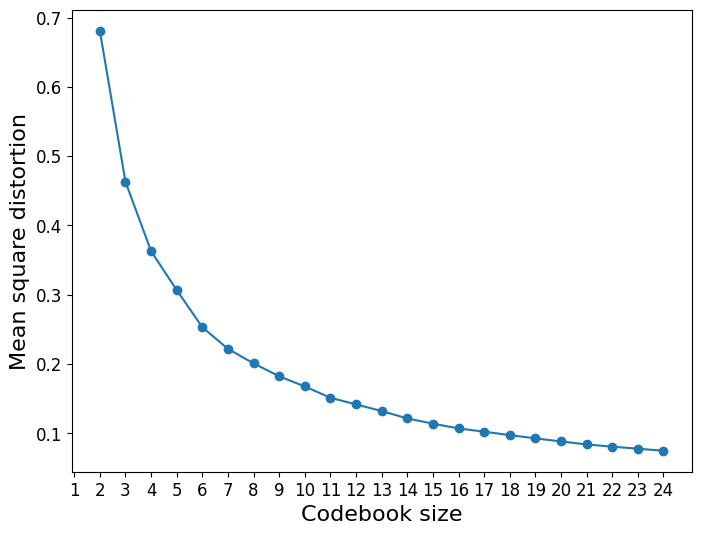

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(range(2,MAX_CODEBOOK_SIZE), distortions, 'o-')
for i,d in enumerate(distortions):
    print(i+1, d)
ax.set_xticks(range(1,MAX_CODEBOOK_SIZE))
ax.set_xlabel("Codebook size", fontsize=16)
ax.set_ylabel("Mean square distortion", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

print(samples[0])

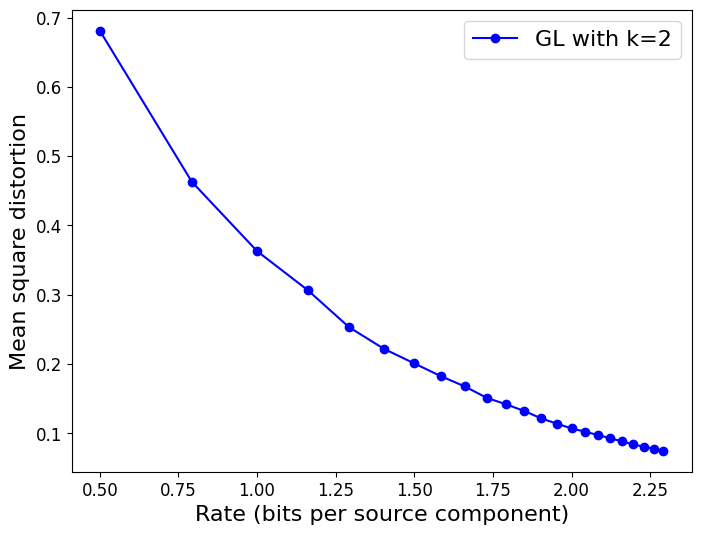

In [ ]:
rate_per_component = [rate/NUM_SAMPLES for rate in rates]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rate_per_component, distortions, 'bo-', label='GL with k=2')
# ax.set_xticks(range(1,MAX_CODEBOOK_SIZE))
ax.set_xlabel("Rate (bits per source component)", fontsize=16)
ax.set_ylabel("Mean square distortion", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

# ax.set_xscale('log')
plt.legend(fontsize=16)



# Theroretical Limit:

D(R) = $2^{-2R}$ for a unit gaussian random variable $N(0,1)$

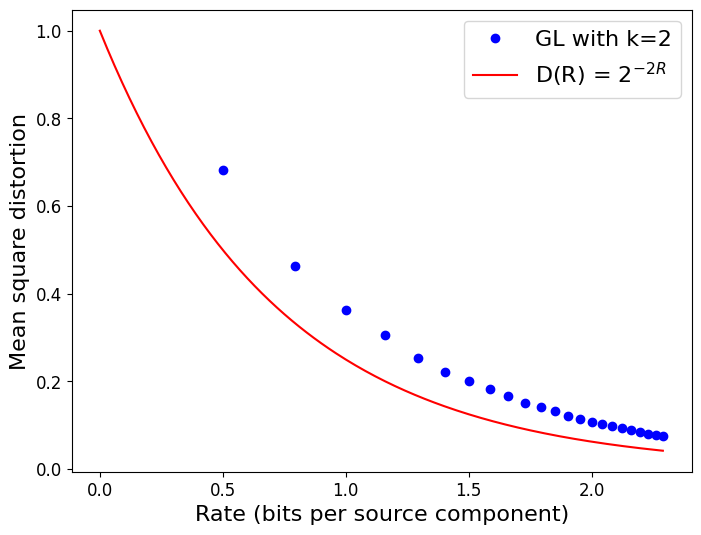

In [ ]:
theoretical_rate = np.arange(0,np.max(rate_per_component),0.01)
theoretical_dist_limit = [2**(-2*rate) for rate in theoretical_rate]


fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rate_per_component, distortions, 'bo', label='GL with k=2')
ax.plot(theoretical_rate, theoretical_dist_limit, 'r-', label='D(R) = $2^{-2R}$')
# ax.set_xticks(range(1,MAX_CODEBOOK_SIZE))
ax.set_xlabel("Rate (bits per source component)", fontsize=16)
ax.set_ylabel("Mean square distortion", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

# ax.set_xscale('log')
plt.legend(fontsize=16)

*Rate assuming NUM_SAMPLES(=n) are transmitted* \\

uncompressed rate = $n * \frac{log_2{n}}{2}$ \\
compressed rate = $n * \frac{log_2{k}}{2}$

where $k$ is the size of the codebook and 2 is the block-length since we are compressing 2D points.


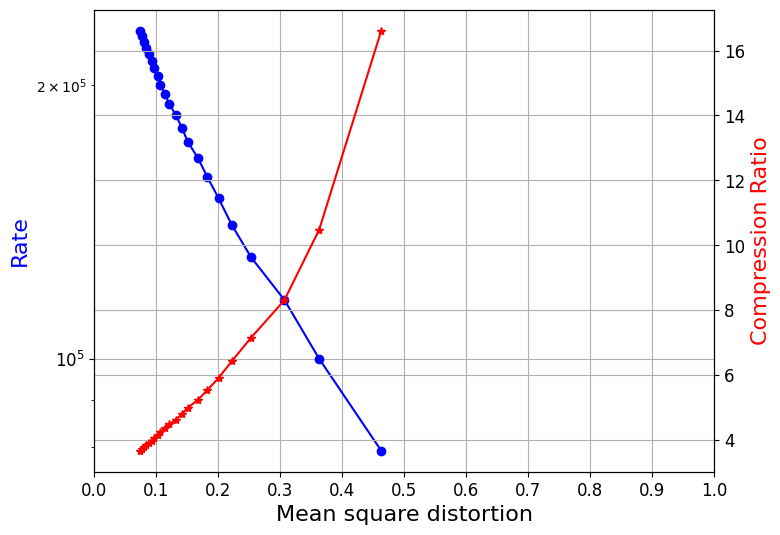

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 6))

ax2 = ax1.twinx()

ax1.plot(distortions[1:], rates[1:], 'bo-')
ax2.plot(distortions[1:], compression_ratio[:-1], 'r*-')

# ax1.hlines(uncompressed_rate, 0, 1, 'k', 'dashed')
# ax1.text(0.7, 9500, 'Uncompressed Rate', color='k', fontsize=12)

ax1.set_xticks(np.arange(0,1.1,0.1))
ax1.set_xlabel("Mean square distortion", fontsize=16)
ax1.set_ylabel("Rate", fontsize=16, color='b')
ax2.set_ylabel("Compression Ratio", fontsize=16, color='r')

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

ax1.set_yscale('log')

ax1.grid()
ax2.grid()

plt.show()

# k-means on images

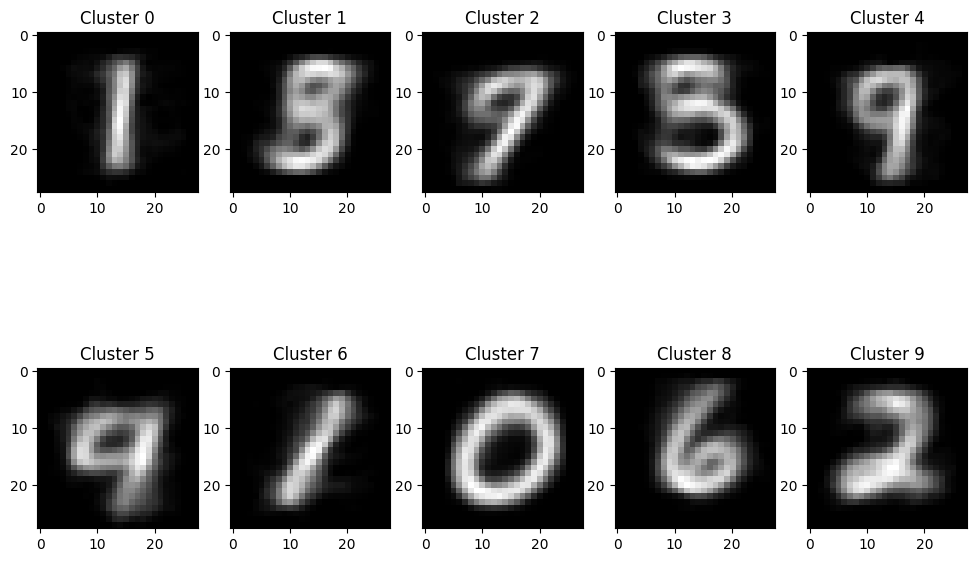

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Download MNIST dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28 * 28)  # Flatten images

# Take a random sample of 100 images
sample_size = 1000
random_indices = np.random.choice(len(x_train), size=sample_size, replace=False)
sample_images = x_train[random_indices]

# Perform K-means clustering with 10 clusters
k = 10
kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
cluster_labels = kmeans.fit_predict(sample_images)

# Visualize the clustered images
plt.figure(figsize=(12, 8))
for i in range(k):
    cluster_indices = np.where(cluster_labels == i)
    cluster_images = sample_images[cluster_indices]

    plt.subplot(2, 5, i + 1)
    cluster_center = kmeans.cluster_centers_[i].reshape(28, 28)
    plt.imshow(cluster_center, cmap='gray')
    plt.title(f'Cluster {i}')

plt.show()

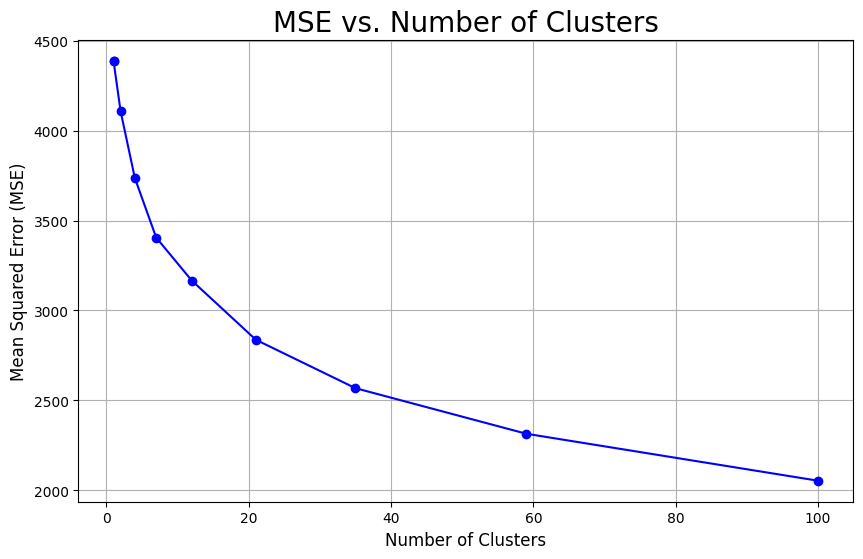

In [ ]:
sample_size = 1000
random_indices = np.random.choice(len(x_train), size=sample_size, replace=False)
sample_images = x_train[random_indices]

# Define a range of cluster numbers to test
cluster_range = np.logspace(0, 2, 10).astype('int')
mse_values = []

# Calculate MSE for different numbers of clusters
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    cluster_labels = kmeans.fit_predict(sample_images)
    cluster_centers = kmeans.cluster_centers_

    # Calculate Mean Squared Error (MSE)
    mse = np.mean(np.square(sample_images - cluster_centers[cluster_labels]))
    mse_values.append(mse)

# Plot the MSE values for different cluster numbers
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, mse_values, marker='o', linestyle='-', color='b')
plt.title('MSE vs. Number of Clusters', fontsize=20)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(True)
plt.show()